In [16]:
# -*- coding: utf-8 -*-
"""
Time Integration – Reduced OWT Model
Damped & Undamped – Harmonic & Ship Impact Loading
"""

# =====================================================
# IMPORTS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from newmark import newmark
import sys as sys


plt.close('all')


def compute_amplitude(q, dof):
    signal = q[dof, :]
    return 0.5 * (np.max(signal) - np.min(signal))

# =====================================================
# PLOT STYLE (CLEAN PROFESSIONAL LAYOUT)
# =====================================================

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.figsize": (12,4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 0.1
})

COLOR_UNDAMPED = "black"
COLOR_DAMPED   = "#d62728"
COLOR_SHIP     = "#2ca02c"
COLOR_HARMONIC = "#1f77b4"

# =====================================================
# LOAD REDUCED MODEL
# =====================================================

data = np.load('ReducedOutput.npz')

K = data['K']
M = data['M']
S = data['S']
omega = data['omega']
Id = data['id_vec']
Is = data['is_vec']

id_idx = Id - 1
is_idx = Is - 1

ndof = K.shape[0]

# =====================================================
# TIME PARAMETERS
# =====================================================

N  = 2000
dt = 0.01
t  = np.arange(0, N+1) * dt

omega_2 = omega[2-1]
omega_13 = omega[13-1]

T_f = 2*np.pi / omega_13



# =====================================================
# RAYLEIGH DAMPING MATRIX
# =====================================================

zeta_target = 0.025

# Rayleigh damping (modes 2 and 13)

A = np.array([
    [1/(2*omega_2), omega_2/2],
    [1/(2*omega_13), omega_13/2]
])
B = np.array([zeta_target, zeta_target])

aR, bR = np.linalg.solve(A, B)

C_rayleigh = aR*M + bR*K

# Print coefficients for verification
print(f"Rayleigh coefficients calculated for modes 2 and 13:")
print(f"alpha (aR) = {aR:.6f}")
print(f"beta  (bR) = {bR:.6f}")

Rayleigh coefficients calculated for modes 2 and 13:
alpha (aR) = 0.051742
beta  (bR) = 0.004835


In [17]:

data_vis = np.load('sysred_vis.npz')

c_opt = 92852341.37932391

w_bar = data_vis['w']                     #### Different size because reduced system

C_viscous_matrix = c_opt * np.dot(w_bar, w_bar.T)

display(C_viscous_matrix[112-1][112-1])
display(C_rayleigh[112-1][112-1])
display(2*np.sqrt(K[112-1][112-1]*M[112-1][112-1]))

np.float64(5942549848.276731)

np.float64(1852705221.6385407)

np.float64(235109972.67842054)

In [18]:
# =====================================================
# RAYLEIGH DAMPING BREAKDOWN PLOT
# =====================================================

omega_min = np.sqrt(aR / bR)

omega_plot = np.linspace(np.min(omega), np.max(omega), 500)

zeta_alpha = aR / (2 * omega_plot)
zeta_beta  = bR * omega_plot / 2
zeta_total = zeta_alpha + zeta_beta

zeta_min = aR / (2 * omega_min) + bR * omega_min / 2

x = omega_plot / omega_min
y_alpha = zeta_alpha / zeta_min
y_beta  = zeta_beta / zeta_min
y_total = zeta_total / zeta_min

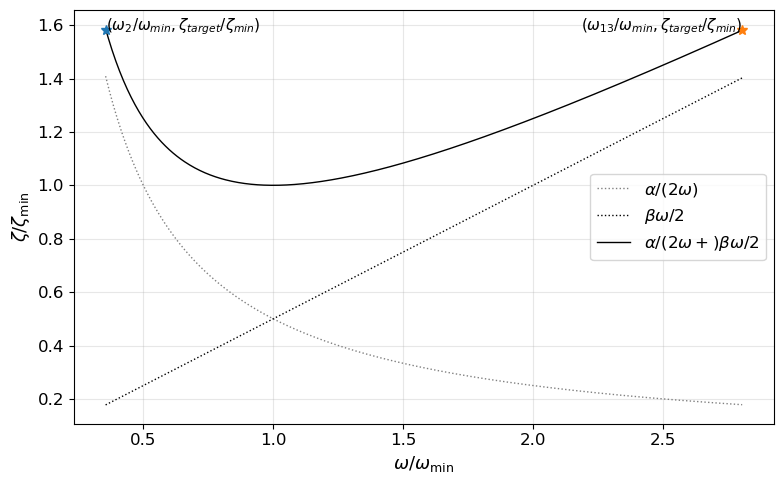

In [19]:
# =====================================================
# FIGURE
# =====================================================

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(x, y_alpha, linestyle=':',linewidth = 1,color = 'grey', label=r'$\alpha/(2\omega)$')
ax.plot(x, y_beta,  linestyle='dotted',linewidth = 1,color = 'black', label=r'$\beta\omega/2$')
ax.plot(x, y_total, linestyle='-',linewidth = 1, color = 'black', label=r'$\alpha/(2\omega+)\beta\omega/2$')
ax.plot(omega_2/omega_min, zeta_target/zeta_min, marker='*',markersize = 7)
ax.plot(omega_13/omega_min, zeta_target/zeta_min, marker='*',markersize = 7)

ax.text(omega_2/omega_min, zeta_target/zeta_min,
        r'$(\omega_{2}/\omega_{min}, \zeta_{target}/\zeta_{min})$',
        fontsize=11,
        ha='left',
        va='baseline')
ax.text(omega_13/omega_min, zeta_target/zeta_min,
        r'$(\omega_{13}/\omega_{min}, \zeta_{target}/\zeta_{min})$',
        fontsize=11,
        ha='right',
        va='baseline')


ax.set_xlabel(r'$\omega / \omega_{\min}$')
ax.set_ylabel(r'$\zeta / \zeta_{\min}$')

#ax.set_title("Rayleigh Damping Decomposition")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# =====================================================
# =====================================================
# LOADING DEFINITIONS
# =====================================================
# =====================================================

target_global = (41-1)*6 + (2-1)

# ---- Global load location (node 50, DOF 2) ----
global_dof = (50-1)*6 + (2-1)

# Full load matrix
F_full = np.zeros((6*279, N+1))

# -------------------------------------------------
# 1. HARMONIC LOAD
# -------------------------------------------------

F0 = 0.6e6
F_full[:] = 0
F_full[global_dof,:] = F0*np.sin(omega_13*t)

F_d = F_full[id_idx,:]
F_s = F_full[is_idx,:]
F_harm = F_d + S.T @ F_s


# -------------------------------------------------
# 2. SHIP IMPACT (DOUBLE HALF-SINE PULSE)
# -------------------------------------------------

ship = np.zeros_like(t)

# First pulse: 0 <= t <= T_f/2
mask1 = (t >= 0) & (t <= T_f/2)
ship[mask1] = 10 * F0 * np.sin(np.pi * t[mask1] / (T_f/2))

# Second pulse: T_f <= t <= T_f + T_f/2
mask2 = (t >= T_f) & (t <= T_f + T_f/2)
ship[mask2] = 10 * F0 * np.sin(np.pi * (t[mask2] - T_f) / (T_f/2))

# Apply to global load vector
F_full = np.zeros((6*279, N+1))
F_full[global_dof, :] = ship

F_d = F_full[id_idx, :]
F_s = F_full[is_idx, :]
F_ship = F_d + S.T @ F_s

In [21]:
# =====================================================
# INITIAL CONDITIONS
# =====================================================

x0 = np.zeros((ndof,1))
v0 = np.zeros((ndof,1))


#Average acceleration
gamma = 0.5
beta  = 0.25

# =====================================================
# TIME INTEGRATION
# =====================================================

# No damper
C = C_rayleigh 
q_h_u, v, a, t = newmark(K,C,M,x0,v0,dt,N,F_harm,beta,gamma)
q_s_u, v, a, t = newmark(K,C,M,x0,v0,dt,N,F_ship,beta,gamma)


# With damper
C = C_rayleigh + C_viscous_matrix
q_h_d, v, a, t = newmark(K,C,M,x0,v0,dt,N,F_harm,beta,gamma)
q_s_d, v, a, t = newmark(K,C,M,x0,v0,dt,N,F_ship,beta,gamma)


# =====================================================
# SELECT DOF TO PLOT (Node 41, DOF 2)
# =====================================================

target_global = (41-1)*6 + (2-1)

if target_global in id_idx:
    plot_dof = np.where(id_idx == target_global)[0][0]
else:
    raise ValueError("Selected node is condensed out!")

A_h_u = compute_amplitude(q_h_u, plot_dof)
A_h_d = compute_amplitude(q_h_d, plot_dof)

A_s_u = compute_amplitude(q_s_u, plot_dof)
A_s_d = compute_amplitude(q_s_d, plot_dof)

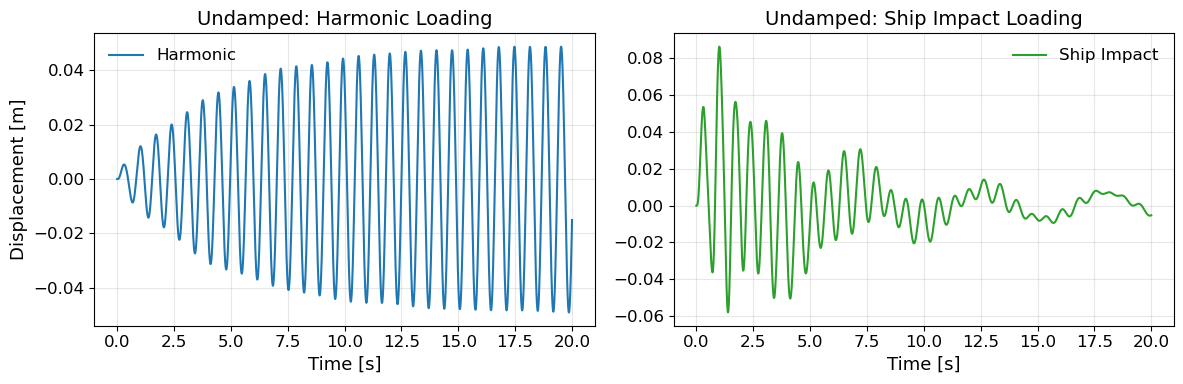

In [22]:
# =====================================================
# UNDAMPED ONLY COMPARISON (SIDE-BY-SIDE)
# =====================================================

fig2, ax2 = plt.subplots(1, 2, figsize=(12,4))

# ---- Harmonic (Undamped) ----
ax2[0].plot(t, q_h_u[plot_dof,:],
            linestyle='-',
            linewidth=1.5,
            color=COLOR_HARMONIC,
            label='Harmonic')

ax2[0].set_title("Undamped: Harmonic Loading")
ax2[0].set_xlabel("Time [s]")
ax2[0].set_ylabel("Displacement [m]")
ax2[0].legend(frameon=False)
ax2[0].grid(True, alpha=0.3)

# ---- Ship Impact (Undamped) ----
ax2[1].plot(t, q_s_u[plot_dof,:],
            linestyle='-',
            linewidth=1.5,
            color=COLOR_SHIP,
            label='Ship Impact')

ax2[1].set_title("Undamped: Ship Impact Loading")
ax2[1].set_xlabel("Time [s]")
ax2[1].legend(frameon=False)
ax2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("TimeIntegration_UndampedOnly.png", dpi=300)
plt.show()


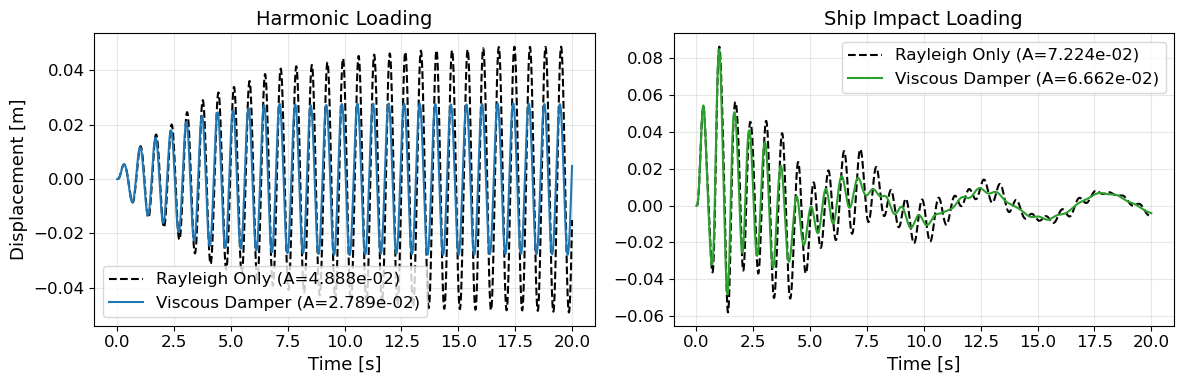

In [23]:
# =====================================================
# COMPARSION OF DAMPED AND UNDAMPED
# =====================================================

fig, ax = plt.subplots(1,2)

# ---- Harmonic ----
ax[0].plot(t, q_h_u[plot_dof,:],
           linestyle='--',
           linewidth = 1.5,
           color=COLOR_UNDAMPED,
           label=f'Rayleigh Only (A={A_h_u:.3e})')

ax[0].plot(t, q_h_d[plot_dof,:],
           linestyle='-',
           linewidth = 1.5,
           color=COLOR_HARMONIC,
           label=f'Viscous Damper (A={A_h_d:.3e})')

ax[0].set_title("Harmonic Loading")
ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("Displacement [m]")
ax[0].legend()
ax[0].legend(loc='lower left')

# ---- Ship ----
ax[1].plot(t, q_s_u[plot_dof,:],
           linestyle='--',
           linewidth = 1.5,
           color=COLOR_UNDAMPED,
           label=f'Rayleigh Only (A={A_s_u:.3e})')

ax[1].plot(t, q_s_d[plot_dof,:],
           linestyle='-',
           linewidth = 1.5,
           color=COLOR_SHIP,
           label=f'Viscous Damper (A={A_s_d:.3e})')

ax[1].set_title("Ship Impact Loading")
ax[1].set_xlabel("Time [s]")
ax[1].legend()
ax[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig("TimeIntegration_Comparison.png", dpi=300)
plt.show()



#sys.exit()

In [24]:
# =====================================================
# DISSIPATED ENERGY CALCULATION
# =====================================================

C = C_rayleigh + C_viscous_matrix
q_h_d, v_h_d, a, t = newmark(K,C,M,x0,v0,dt,N,F_harm,beta,gamma)
q_s_d, v_s_d, a, t = newmark(K,C,M,x0,v0,dt,N,F_ship,beta,gamma)
# Power dissipated at each time step:
# P(t) = v^T * C_viscous * v

# Harmonic case
P_h = np.zeros(N+1)
for i in range(N+1):
    v_i = v[:, i]
    P_h[i] = v_i.T @ C_viscous_matrix @ v_i

# Ship impact case
P_s = np.zeros(N+1)
for i in range(N+1):
    v_i = v[:, i]   # CAREFUL: must use ship velocities!
    P_s[i] = v_i.T @ C_viscous_matrix @ v_i



# Harmonic
P_h = np.zeros(N+1)
for i in range(N+1):
    v_i = v[:, i]
    P_h[i] = v_i.T @ C_viscous_matrix @ v_i

# Ship
P_s = np.zeros(N+1)
for i in range(N+1):
    v_i = v[:, i]
    P_s[i] = v_i.T @ C_viscous_matrix @ v_i



# Cumulative energy using trapezoidal integration
E_h = np.zeros(N+1)
E_s = np.zeros(N+1)

E_h[1:] = np.cumsum(0.5 * (P_h[1:] + P_h[:-1]) * dt)
E_s[1:] = np.cumsum(0.5 * (P_s[1:] + P_s[:-1]) * dt)

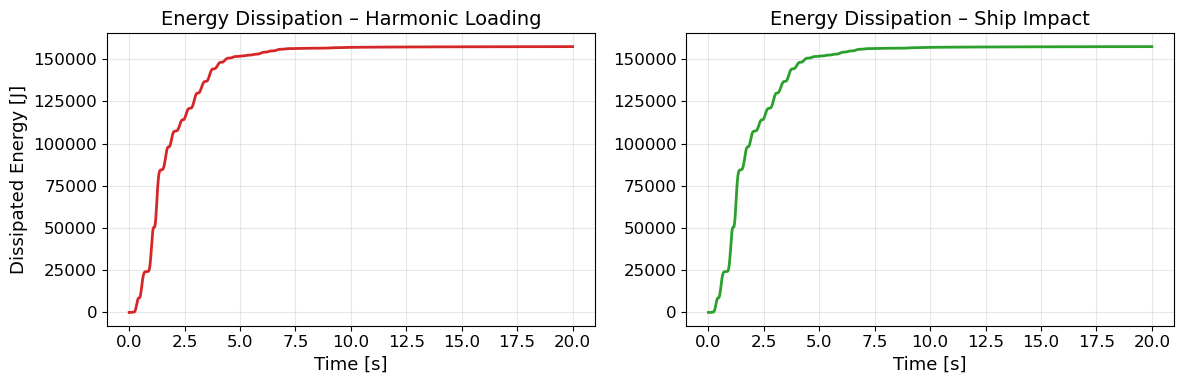

In [25]:
# =====================================================
# PLOT DISSIPATED ENERGY
# =====================================================

fig4, ax4 = plt.subplots(1, 2, figsize=(12,4))

# Harmonic
ax4[0].plot(t, E_h,
            linewidth=2,
            color=COLOR_DAMPED)

ax4[0].set_title("Energy Dissipation – Harmonic Loading")
ax4[0].set_xlabel("Time [s]")
ax4[0].set_ylabel("Dissipated Energy [J]")
ax4[0].grid(True, alpha=0.3)

# Ship
ax4[1].plot(t, E_s,
            linewidth=2,
            color=COLOR_SHIP)

ax4[1].set_title("Energy Dissipation – Ship Impact")
ax4[1].set_xlabel("Time [s]")
ax4[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("DissipatedEnergy.png", dpi=300)
plt.show()


In [26]:
# =====================================================
# TOTAL DAMPING MATRIX
# =====================================================

C_total = C_rayleigh + C_viscous_matrix


# =====================================================
# FUNCTION: COMPUTE TOTAL ENERGY
# =====================================================

def compute_energy(v):
    P_viscous = np.zeros(N+1)
    P_total   = np.zeros(N+1)

    for i in range(N+1):
        v_i = v[:, i]

        # viscous damper only
        P_viscous[i] = v_i.T @ C_viscous_matrix @ v_i

        # full damping system
        P_total[i] = v_i.T @ C_total @ v_i

    # integrate power → energy
    E_viscous = np.cumsum(0.5*(P_viscous[1:] + P_viscous[:-1]) * dt)
    E_total   = np.cumsum(0.5*(P_total[1:] + P_total[:-1]) * dt)

    # prepend zero
    E_viscous = np.insert(E_viscous, 0, 0.0)
    E_total   = np.insert(E_total, 0, 0.0)

    return E_viscous, E_total


# =====================================================
# HARMONIC CASE
# =====================================================

E_h_visc, E_h_total = compute_energy(v_h_d)

# =====================================================
# SHIP CASE
# =====================================================

E_s_visc, E_s_total = compute_energy(v_s_d)


# =====================================================
# FINAL VALUES (END OF SIMULATION)
# =====================================================

print("\n================ ENERGY DISSIPATION SUMMARY ================\n")

print("HARMONIC LOADING:")
print(f"  Viscous damper energy:      {E_h_visc[-1]:.3e} J")
print(f"  Full system damping energy:  {E_h_total[-1]:.3e} J")
print(f"  Viscous contribution:       {100*E_h_visc[-1]/E_h_total[-1]:.2f} %\n")

print("SHIP IMPACT LOADING:")
print(f"  Viscous damper energy:      {E_s_visc[-1]:.3e} J")
print(f"  Full system damping energy:  {E_s_total[-1]:.3e} J")
print(f"  Viscous contribution:       {100*E_s_visc[-1]/E_s_total[-1]:.2f} %\n")

print("===========================================================\n")



================ ENERGY DISSIPATION SUMMARY ================

HARMONIC LOADING:
  Viscous damper energy:      2.296e+05 J
  Full system damping energy:  5.631e+05 J
  Viscous contribution:       40.77 %

SHIP IMPACT LOADING:
  Viscous damper energy:      1.574e+05 J
  Full system damping energy:  4.427e+05 J
  Viscous contribution:       35.56 %




In [29]:
# =====================================================
# LOAD FULL SYSTEM (FOR MODAL COMPARISON)
# =====================================================

full_data = np.load('owt_XKM.npz')
K_full = full_data['K']
M_full = full_data['M']

ndof_full = K_full.shape[0]

# =====================================================
# BUILD FULL LOAD MATRICES (FOR MODAL ANALYSIS)
# =====================================================

F_full_harm = np.zeros((ndof_full, N+1))
F_full_ship = np.zeros((ndof_full, N+1))

F_full_harm[global_dof, :] = F0*np.sin(omega_13*t)
F_full_ship[global_dof, :] = ship

# =====================================================
# FULL SYSTEM MODAL ANALYSIS (50 MODES)
# =====================================================

import scipy as sp

n_modes = 50
zeta_modal = 0.025

# Eigenvalue problem (FULL system)
lam_full, Phi_full = sp.linalg.eigh(
    K_full, M_full,
    subset_by_index=[0, n_modes-1]
)

omega_full = np.sqrt(np.real(lam_full))

# ---- Mass normalize ----
for j in range(n_modes):
    mj = Phi_full[:, j].T @ M_full @ Phi_full[:, j]
    Phi_full[:, j] /= np.sqrt(mj)

# Modal matrices
M_modal = np.eye(n_modes)
K_modal = np.diag(omega_full**2)
C_modal = np.diag(2*zeta_modal*omega_full)

# Transform loads
Fh_modal = Phi_full.T @ F_full_harm
Fs_modal = Phi_full.T @ F_full_ship

# Initial conditions
eta0 = np.zeros((n_modes,1))
eta_dot0 = np.zeros((n_modes,1))

# Harmonic response
eta_h, _, _, _ = newmark(
    K_modal, C_modal, M_modal,
    eta0, eta_dot0,
    dt, N,
    Fh_modal,
    beta, gamma
)

# Ship response
eta_s, _, _, _ = newmark(
    K_modal, C_modal, M_modal,
    eta0, eta_dot0,
    dt, N,
    Fs_modal,
    beta, gamma
)

# Back to physical coordinates
q_full_modal_h = Phi_full @ eta_h
q_full_modal_s = Phi_full @ eta_s

target_full = (41-1)*6 + (2-1)

A_h_f = compute_amplitude(q_full_modal_h, plot_dof)
A_s_f = compute_amplitude(q_full_modal_s, plot_dof)


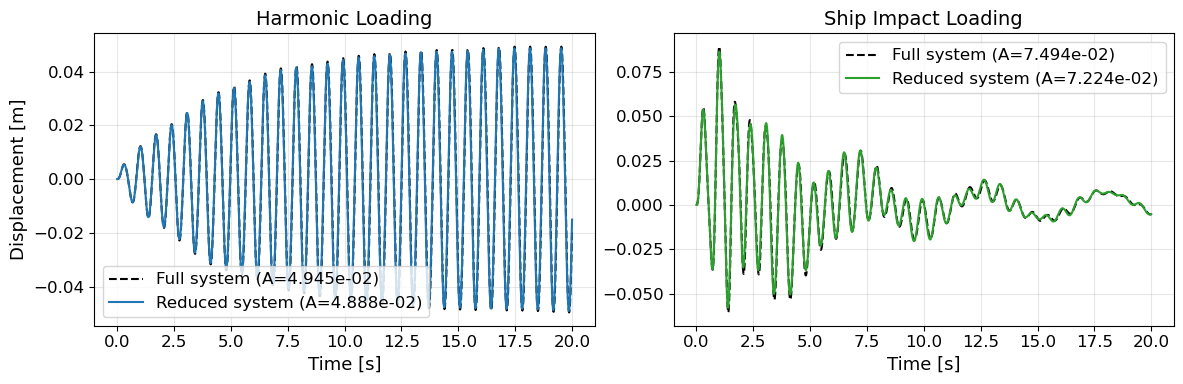

In [30]:
# =====================================================
# FULL vs REDUCED SYSTEM COMPARISON (MODAL – 50 MODES)
# =====================================================

fig3, ax3 = plt.subplots(1, 2, figsize=(12,4))

# -----------------------------------------------------
# Harmonic Loading
# -----------------------------------------------------

ax3[0].plot(t, q_full_modal_h[target_full,:],
            color=COLOR_UNDAMPED,
            linestyle='--',
            linewidth=1.5,
            label=f'Full system (A={A_h_f:.3e})')

ax3[0].plot(t, q_h_u[plot_dof,:],
            linestyle='-',
            linewidth=1.5,
            color=COLOR_HARMONIC,
            label=f'Reduced system (A={A_h_u:.3e})')

ax3[0].set_title("Harmonic Loading")
ax3[0].set_xlabel("Time [s]")
ax3[0].set_ylabel("Displacement [m]")
ax3[0].legend()
ax3[0].grid(True, alpha=0.3)

ax3[0].legend(loc='lower left')



# -----------------------------------------------------
# Ship Impact Loading
# -----------------------------------------------------

ax3[1].plot(t, q_full_modal_s[target_full,:],
            color=COLOR_UNDAMPED,
            linestyle='--',
            linewidth=1.5,
            label=f'Full system (A={A_s_f:.3e})')

ax3[1].plot(t, q_s_u[plot_dof,:],
            linestyle='-',
            linewidth=1.5,
            color=COLOR_SHIP,
            label=f'Reduced system (A={A_s_u:.3e})')

ax3[1].set_title("Ship Impact Loading")
ax3[1].set_xlabel("Time [s]")
ax3[1].legend()
ax3[1].grid(True, alpha=0.3)
ax3[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig("Full_vs_Reduced_ModalComparison.png", dpi=300)
plt.show()


In [45]:
# =====================================================
# (e) TMD – AUGMENTED OWT–TMD SYSTEM
# =====================================================

# ---- Load optimal TMD parameters ----
data_tmd = np.load('sysred_TMD.npz')
print(data_tmd)

m_tmd = 1946
print(m_tmd)
c_tmd = data_tmd['c']     # TMD damping
print(c_tmd)
k_tmd = data_tmd['k']     # TMD stiffness
print(k_tmd)
w_tmd = data_tmd['w']         # location vector (reduced system size)
#M_tmd = data_tmd['m_TMD']         # currently not in use


# Ensure column vector
w_tmd = w_tmd.reshape(-1,1)

# -----------------------------------------------------
# BUILD AUGMENTED MATRICES

ndof_aug = ndof + 1   # extra DOF for TMD

M_aug = np.zeros((ndof_aug, ndof_aug))
K_aug = np.zeros((ndof_aug, ndof_aug))
C_aug = np.zeros((ndof_aug, ndof_aug))

# --- Structural part ---
M_aug[:ndof,:ndof] = M
K_aug[:ndof,:ndof] = K
C_aug[:ndof,:ndof] = C_rayleigh

# --- TMD mass ---
M_aug[-1,-1] = m_tmd

# --- TMD stiffness coupling ---
K_aug[:ndof,:ndof] += k_tmd * (w_tmd @ w_tmd.T)
K_aug[:ndof,-1]     = -k_tmd * w_tmd[:,0]
K_aug[-1,:ndof]     = -k_tmd * w_tmd[:,0]
K_aug[-1,-1]        = k_tmd

# --- TMD damping coupling ---
C_aug[:ndof,:ndof] += c_tmd * (w_tmd @ w_tmd.T)
C_aug[:ndof,-1]     = -c_tmd * w_tmd[:,0]
C_aug[-1,:ndof]     = -c_tmd * w_tmd[:,0]
C_aug[-1,-1]        = c_tmd







# -----------------------------------------------------
# AUGMENT LOAD VECTOR

F_harm_aug = np.zeros((ndof_aug, N+1))
F_ship_aug = np.zeros((ndof_aug, N+1))

F_harm_aug[global_dof,:] = F0*np.sin(omega_13*t)
F_ship_aug[:ndof,:] = F_ship
#F_ship_aug[global_dof,:] = ship
# (TMD DOF has no external load)





NpzFile 'sysred_TMD.npz' with keys: w, c, k, m_TMD, m_13_norm
1946
1423.743793026606
162757.50218194793


In [46]:
# -----------------------------------------------------
# INITIAL CONDITIONS


x0_aug = np.zeros((ndof_aug,1))
v0_aug = np.zeros((ndof_aug,1))

# -----------------------------------------------------
# TIME INTEGRATION – TMD SYSTEM

q_h_tmd, v, a, t = newmark(K_aug, C_aug, M_aug,
                           x0_aug, v0_aug, dt, N,
                           F_harm_aug, beta, gamma)

q_s_tmd, v, a, t = newmark(K_aug, C_aug, M_aug,
                           x0_aug, v0_aug, dt, N,
                           F_ship_aug, beta, gamma)

# Extract structural response only
q_h_tmd_struct = q_h_tmd[:ndof,:]
q_s_tmd_struct = q_s_tmd[:ndof,:]




A_h_tmd = compute_amplitude(q_h_tmd_struct, plot_dof)
A_s_tmd = compute_amplitude(q_s_tmd_struct, plot_dof)



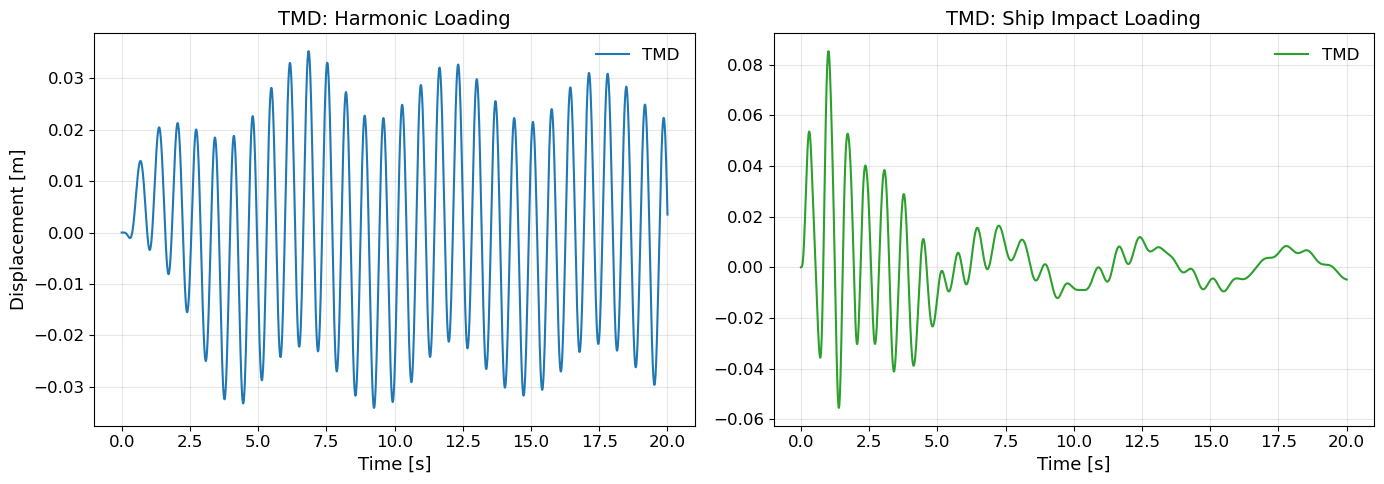

In [47]:
# -----------------------------------------------------
# TMD RESPONSE ONLY (NEW FIGURE)


fig_tmd, ax_tmd = plt.subplots(1, 2, figsize=(14,5))

# ---- Harmonic ----
ax_tmd[0].plot(t, q_h_tmd_struct[plot_dof,:],
               linewidth=1.5,
               label='TMD',
               color=COLOR_HARMONIC)

ax_tmd[0].set_title("TMD: Harmonic Loading")
ax_tmd[0].set_xlabel("Time [s]")
ax_tmd[0].set_ylabel("Displacement [m]")
ax_tmd[0].legend(frameon=False)
ax_tmd[0].grid(True, alpha=0.3)

# ---- Ship Impact ----
ax_tmd[1].plot(t, q_s_tmd_struct[plot_dof,:],
               linewidth=1.5,
               label='TMD',
               color=COLOR_SHIP)

ax_tmd[1].set_title("TMD: Ship Impact Loading")
ax_tmd[1].set_xlabel("Time [s]")
ax_tmd[1].legend(frameon=False)
ax_tmd[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("TimeIntegration_TMD_Only.png", dpi=300)
plt.show()


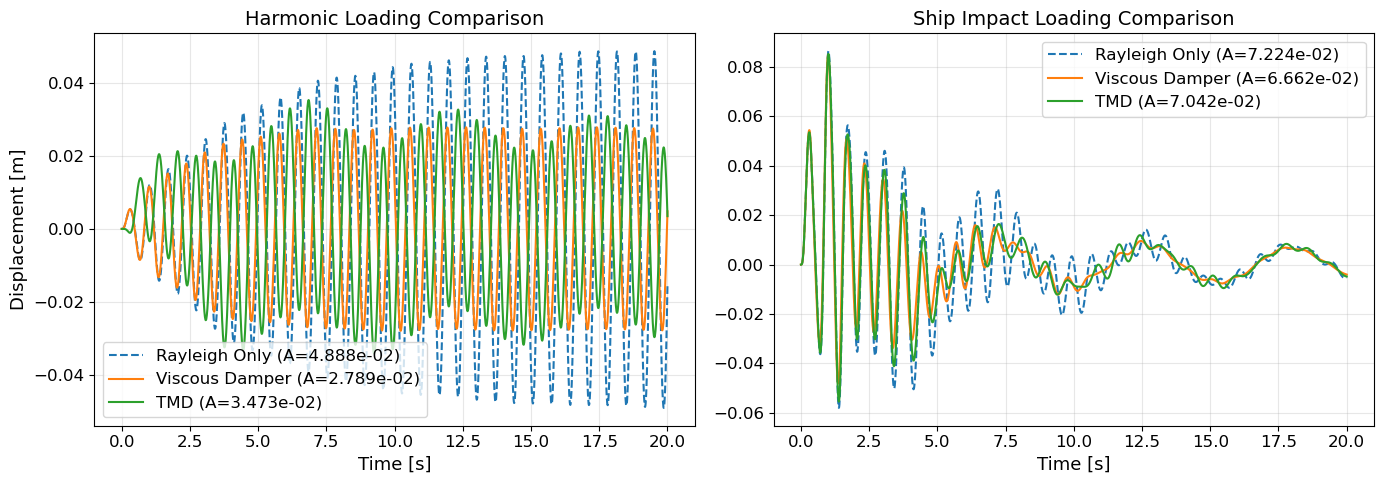

In [48]:


# -----------------------------------------------------
# FULL COMPARISON: RAYLEIGH vs VISCOUS vs TMD


fig_comp, ax_comp = plt.subplots(1, 2, figsize=(14,5))

# ---- Harmonic Loading ----
ax_comp[0].plot(t, q_h_u[plot_dof,:],
                linestyle='--',
                linewidth=1.5,
                label=f'Rayleigh Only (A={A_h_u:.3e})')

ax_comp[0].plot(t, q_h_d[plot_dof,:],
                linestyle='-',
                linewidth=1.5,
                label=f'Viscous Damper (A={A_h_d:.3e})')

ax_comp[0].plot(t, q_h_tmd_struct[plot_dof,:],
                linestyle='-',
                linewidth=1.5,
                label=f'TMD (A={A_h_tmd:.3e})')



ax_comp[0].set_title("Harmonic Loading Comparison")
ax_comp[0].set_xlabel("Time [s]")
ax_comp[0].set_ylabel("Displacement [m]")
ax_comp[0].legend()
ax_comp[0].grid(True, alpha=0.3)
ax_comp[0].legend(loc='lower left')

# ---- Ship Impact Loading ----
ax_comp[1].plot(t, q_s_u[plot_dof,:],
                linestyle='--',
                linewidth=1.5,
                label=f'Rayleigh Only (A={A_s_u:.3e})')

ax_comp[1].plot(t, q_s_d[plot_dof,:],
                linestyle='-',
                linewidth=1.5,
                label=f'Viscous Damper (A={A_s_d:.3e})')

ax_comp[1].plot(t, q_s_tmd_struct[plot_dof,:],
                linestyle='-',
                linewidth=1.5,
                label=f'TMD (A={A_s_tmd:.3e})')

ax_comp[1].set_title("Ship Impact Loading Comparison")
ax_comp[1].set_xlabel("Time [s]")
ax_comp[1].legend()
ax_comp[1].grid(True, alpha=0.3)
ax_comp[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig("TimeIntegration_Full_Comparison.png", dpi=300)
plt.show()